In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(0)

# parameters
n_dim = 3
centers = [[1, 1, 5], [5, 1, 1], [1, 1, 1], [1, 5, 5]]
std_dev = 0.5
n_points = 100

classes = [np.random.normal(loc=np.array(centers[i]), scale=std_dev, size=(n_points, n_dim)) for i in range(len(centers))]

# Plot the data
# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# for i, class_points in enumerate(classes):
#     ax.scatter(class_points[:, 0], class_points[:, 1], class_points[:, 2], color='k')#, label=f'Class {i+1}')
# ax.set_xlabel('X axis')
# ax.set_ylabel('Y axis')
# ax.set_zlabel('Z axis')
# plt.show()

In [2]:
# randomly shuffle the data points
points = np.vstack(classes)
np.random.shuffle(points)

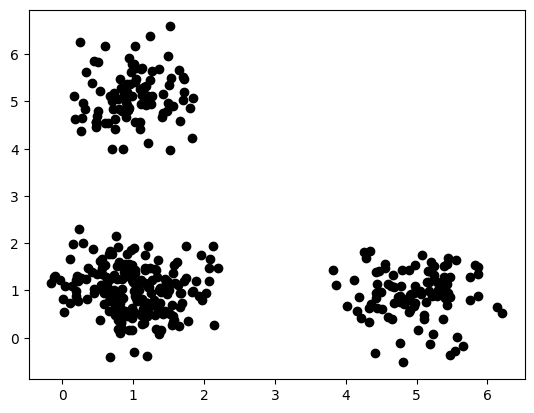

In [3]:
# x and y coordinates for the 2D projection
view1 = points[:, :2]  # first two dimensions

# plot the 2D projection
plt.figure()
plt.scatter(view1[:, 0], view1[:, 1], c='k')

/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_12982/2225837267.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(view1[i, 0], view1[i, 1], c=color, marker='o')


Text(0.5, 1.0, 'K-means Clustering (2D Projection)')

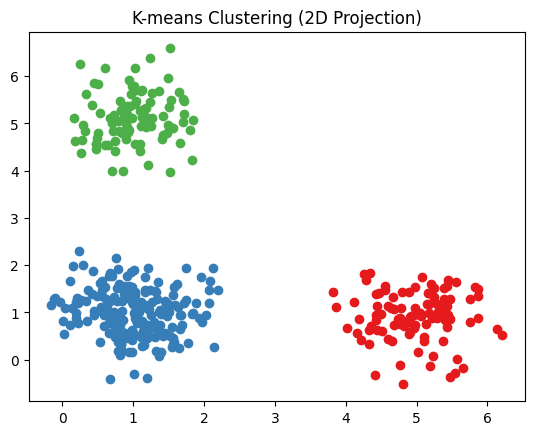

In [4]:
# k-means clustering 2d
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0).fit(view1)

# plot the clusters
plt.figure()
for i in range(len(view1)):
    if kmeans.labels_[i] == 0:
        color = plt.cm.Set1(0)
    elif kmeans.labels_[i] == 1:
        color = plt.cm.Set1(1)
    else:
        color = plt.cm.Set1(2)
    plt.scatter(view1[i, 0], view1[i, 1], c=color, marker='o')

# plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='red', marker='X', s=200, label='Centroids')
plt.title('K-means Clustering (2D Projection)')

([], [])

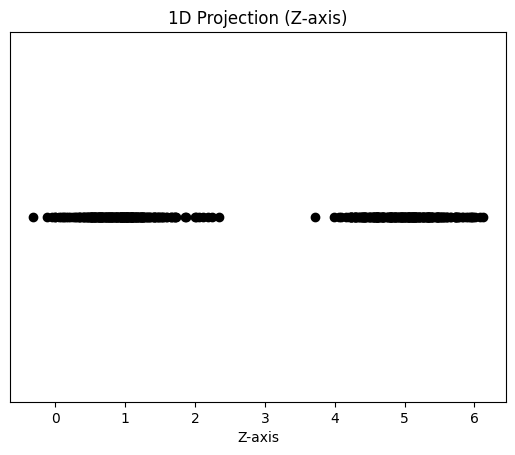

In [10]:
# 1d projection (z)
view2 = points[:, 2]  # third dimension

# plot the 1D projection
plt.figure()
plt.scatter(view2, np.zeros_like(view2), c='k')
plt.title('1D Projection (Z-axis)')
plt.xlabel('Z-axis')
# remove y ticks
plt.yticks([])

([], [])

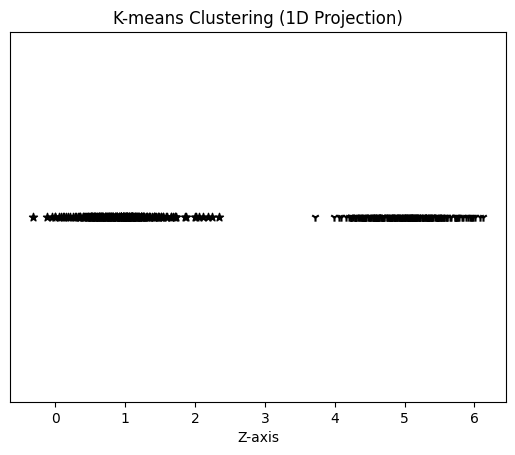

In [11]:
# K-means clustering 1d
kmeans_1d = KMeans(n_clusters=2, random_state=0).fit(view2.reshape(-1, 1))

# plot the clusters (stars and squares)
plt.figure()
for i in range(len(view2)):
    if kmeans_1d.labels_[i] == 0:
        plt.scatter(view2[i], 0, c='k', marker='*')
    else:
        plt.scatter(view2[i], 0, c='k', marker='1')

plt.title('K-means Clustering (1D Projection)')
plt.xlabel('Z-axis')
plt.yticks([])

/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_12982/2337731469.py:13: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[i, 0], points[i, 1], points[i, 2], c=color, marker='*')
/var/folders/qn/sypqqw3101v1k6_70wqyd99h0000gn/T/ipykernel_12982/2337731469.py:15: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[i, 0], points[i, 1], points[i, 2], c=color, marker='1')


Text(0.5, 0.5, 'Y axis')

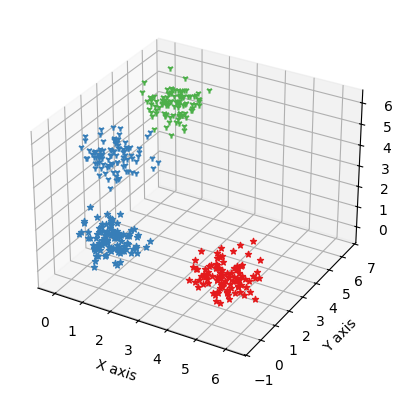

In [7]:
# plot 3d using shape and color to represent the clusters
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for i in range(len(points)):
    if kmeans.labels_[i] == 0:
        # Set1 colormap
        color = plt.cm.Set1(0)
    elif kmeans.labels_[i] == 1:
        color = plt.cm.Set1(1)
    else:
        color = plt.cm.Set1(2)
    if kmeans_1d.labels_[i] == 0:
        ax.scatter(points[i, 0], points[i, 1], points[i, 2], c=color, marker='*')
    else:
        ax.scatter(points[i, 0], points[i, 1], points[i, 2], c=color, marker='1')
ax.set_xlabel('X axis')
ax.set_ylabel('Y axis')

- red implies star
- green implies triangle
- blue implies {star, triangle}

there is no need then to consider the clusters (red, triangle) or (green, star), we can simplify the cluster labels to (red, star) and (green, triangle), (blue, star) and (blue, triangle).

Could be measured by $P(\text{star} | \text{red})$ (in the evidential case: $Pl(\text{star} | \text{red})$ and $Bel(\text{star} | \text{red})$)

Idea of algorithm: exclude (map to empty set) the pairs (color, shape) that have low enough conditional probability (or plausibility/belief), consider the simplified cluster then. For each clustering $\omega_i^1$ start by $\omega_i \rightarrow \Omega^2$ and follow by removing $\omega_j^2$ that have suff low conditional probability.